In [1]:
import sys, kardemumma
print(sys.executable)         # kernel Python
print(kardemumma.__file__)    # should point to your local repo under src/kardemumma

/home/thanadol/Documents/GitHub/kardemumma/.venv/bin/python
/home/thanadol/Documents/GitHub/kardemumma/src/kardemumma/__init__.py


In [2]:
# Load packages
from pathlib import Path
import os
import re
import sys
import importlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from pyteomics import achrom
# Importantly, import kardemumma :)
import kardemumma as kdm

In [3]:

# Skyline data path
skyline_path = "data/DA4000/DA4k_p1-8.csv"

# Import skyline data (includes column "Isotope Label Type" from Precursor)
skyline_importer = kdm.ImportSkylineFile(skyline_path)
skyline_data = skyline_importer.import_skyline_file()

Importing Skyline file: data/DA4000/DA4k_p1-8.csv
File data/DA4000/DA4k_p1-8.csv is valid.


In [4]:
# **SDRF**
sdrf_path = 'data/DA4000/20260523_DA4K.sdrf.tsv'

# Valdate sdrf 
# kdm.validate_sdrf(sdrf_path)
kdm.readout_ms_type(sdrf_path)
# Import SDRF file for this project

sdrf_data = kdm.ImportSDRFFile(sdrf_path)
sdrf_data_file = sdrf_data.import_sdrf_file()



Importing SDRF file: data/DA4000/20260523_DA4K.sdrf.tsv


In [5]:
# Print out what Peptide Sequence iRT

kdm.get_irt_peptides(skyline_data)

Checking if the peptides are from Biognosys...
Not matched: YGVSDYYK, SIELAEAK, ISEATDGLSDFLK, TVEGVKDLQAQVVESAK, SQTPAEDTVK, ELDKYGVSDYHK, YGVSDYHK, NLINNAK, DLQAQVVESAK, ELDKYGVSDYYK
Number of peptides not matching Biognosys: 10

Number of iRT peptides: 10
iRT peptides: ['ELDKYGVSDYHK', 'YGVSDYHK', 'NLINNAK', 'TVEGVKDLQAQVVESAK', 'DLQAQVVESAK', 'ISEATDGLSDFLK', 'SQTPAEDTVK', 'SIELAEAK', 'ELDKYGVSDYYK', 'YGVSDYYK']



['ELDKYGVSDYHK',
 'YGVSDYHK',
 'NLINNAK',
 'TVEGVKDLQAQVVESAK',
 'DLQAQVVESAK',
 'ISEATDGLSDFLK',
 'SQTPAEDTVK',
 'SIELAEAK',
 'ELDKYGVSDYYK',
 'YGVSDYYK']

In [6]:
sdrf_data_file.head()

,source name,characteristics[Row],characteristics[Column],characteristics[Sample],characteristics[organism],characteristics[organism part],characteristics[plate],characteristics[project],characteristics[age],characteristics[developmental stage],...,comment[cleavage agent details],comment[ms2 mass analyzer],comment[instrument],comment[modification parameters],comment[dissociation method],comment[collision energy],comment[precursor mass tolerance],comment[fragment mass tolerance],comment[ProteomEdge],factor value[disease]
0,PRM_20260410_DA_4K_B1_Plate1_A1,A,1,DA4K,Homo sapiens,blood plasma,Plate_1,DA_4K_B1,not available,not available,...,AC=MS:1001251;NT=Trypsin,not available,NT=Stellar;AC=MS:1003409,NT=Carbamidomethyl;AC=UNIMOD:4;TA=C;MT=Fixed,NT=Higher-energy Collisional Dissociation;AC=M...,27 NCE,40 ppm,0.05 Da,24001,Longevity
1,PRM_20260410_DA_4K_B1_Plate1_A2,A,2,DA4K,Homo sapiens,blood plasma,Plate_1,DA_4K_B1,not available,not available,...,AC=MS:1001251;NT=Trypsin,not available,NT=Stellar;AC=MS:1003409,NT=Carbamidomethyl;AC=UNIMOD:4;TA=C;MT=Fixed,NT=Higher-energy Collisional Dissociation;AC=M...,27 NCE,40 ppm,0.05 Da,24001,Longevity
2,PRM_20260410_DA_4K_B1_Plate1_A3,A,3,DA4K,Homo sapiens,blood plasma,Plate_1,DA_4K_B1,not available,not available,...,AC=MS:1001251;NT=Trypsin,not available,NT=Stellar;AC=MS:1003409,NT=Carbamidomethyl;AC=UNIMOD:4;TA=C;MT=Fixed,NT=Higher-energy Collisional Dissociation;AC=M...,27 NCE,40 ppm,0.05 Da,24001,Cerebral Venous Thrombosis
3,PRM_20260410_DA_4K_B1_Plate1_A4,A,4,PlasmaPool,Homo sapiens,blood plasma,Plate_1,DA_4K_B1,not available,not available,...,AC=MS:1001251;NT=Trypsin,not available,NT=Stellar;AC=MS:1003409,NT=Carbamidomethyl;AC=UNIMOD:4;TA=C;MT=Fixed,NT=Higher-energy Collisional Dissociation;AC=M...,27 NCE,40 ppm,0.05 Da,24001,PlasmaPool
4,PRM_20260410_DA_4K_B1_Plate1_A5,A,5,DA4K,Homo sapiens,blood plasma,Plate_1,DA_4K_B1,not available,not available,...,AC=MS:1001251;NT=Trypsin,not available,NT=Stellar;AC=MS:1003409,NT=Carbamidomethyl;AC=UNIMOD:4;TA=C;MT=Fixed,NT=Higher-energy Collisional Dissociation;AC=M...,27 NCE,40 ppm,0.05 Da,24001,Schizophrenia


In [7]:
# Checking possible QC samples from Skyline results

qc_samples = skyline_importer.suggest_qc_samples(skyline_data)
# skyline_checker = CheckSkylineFile(skyline_path)

# Suggest qc samples

print(qc_samples)


Number of possible QC samples: 0
Possible QC samples: []
Consider removing these QC samples before further analysis.
[]


In [8]:
# Plot retention time

skyline_rt = skyline_data.copy()

# Calculate mean retention time for each peptide
mean_rt = skyline_data.groupby('Peptide Sequence')['Predicted Retention Time'].mean()

# Sort peptides by mean retention time
sorted_peptides = mean_rt.sort_values().index.tolist()

# Calculate predicted RT using pyteomics.achrom's calculate_RT with Guo coefficients
skyline_rt['RT'] = skyline_rt['Peptide Sequence'].apply(lambda seq: achrom.calculate_RT(seq, achrom.RCs_guo_ph7_0))

skyline_rt.head()

,Precursor,Replicate,File Name,Peptide Sequence,Peptide,Retention Time Calculator Score,Protein Name,Normalized Area,RatioLightToHeavy,Ratio Dot Product,Library Dot Product,Peptide Retention Time,Predicted Retention Time,Isotope Label Type,Precursor Charge,RT
0,490.5796+++ (heavy),PRM_20260410_DA_4K_B1_Plate1_F3,PRM_20260410_DA_4K_B1_Plate1_F3.raw,ELDKYGVSDYHK,ELDKYGVSDYHK,1,iRT_Tag,NaN,NaN,NaN,0.8392,13.04,13.2,heavy,3,18.5
1,490.5796+++ (heavy),PRM_20260410_DA_4K_B1_Plate1_F7,PRM_20260410_DA_4K_B1_Plate1_F7.raw,ELDKYGVSDYHK,ELDKYGVSDYHK,1,iRT_Tag,NaN,NaN,NaN,0.8467,13.13,13.2,heavy,3,18.5
2,490.5796+++ (heavy),PRM_20260410_DA_4K_B1_Plate1_B12,PRM_20260410_DA_4K_B1_Plate1_B12.raw,ELDKYGVSDYHK,ELDKYGVSDYHK,1,iRT_Tag,NaN,NaN,NaN,0.8760,12.99,13.2,heavy,3,18.5
3,490.5796+++ (heavy),PRM_20260410_DA_4K_B1_Plate1_C9,PRM_20260410_DA_4K_B1_Plate1_C9.raw,ELDKYGVSDYHK,ELDKYGVSDYHK,1,iRT_Tag,NaN,NaN,NaN,0.8661,13.12,13.2,heavy,3,18.5
4,490.5796+++ (heavy),PRM_20260410_DA_4K_B1_Plate1_E1,PRM_20260410_DA_4K_B1_Plate1_E1.raw,ELDKYGVSDYHK,ELDKYGVSDYHK,1,iRT_Tag,NaN,NaN,NaN,0.8819,13.10,13.2,heavy,3,18.5


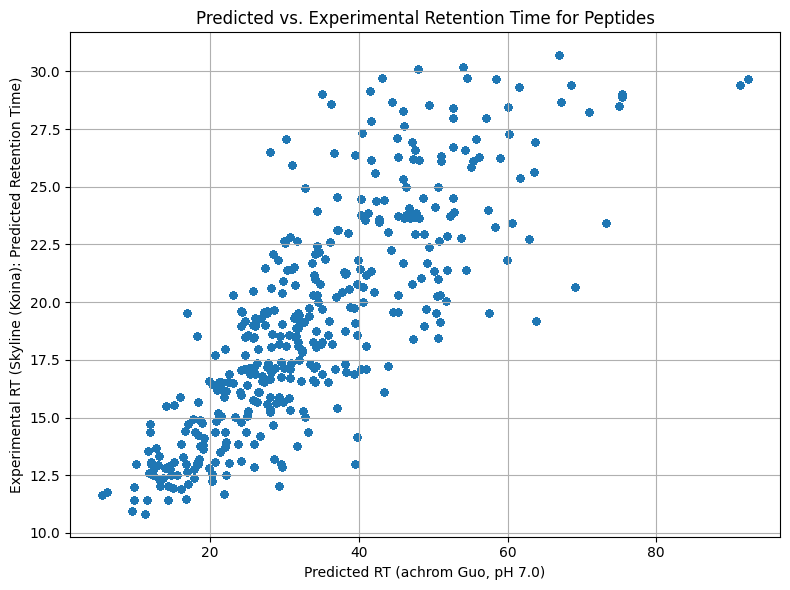

In [9]:
# Plot matching between predicted RT and experimental Predicted Retention Time

plt.figure(figsize=(8, 6))
plt.scatter(
    skyline_rt['RT'],
    skyline_rt['Predicted Retention Time'],
    alpha=0.6,
    s=20
)
plt.xlabel('Predicted RT (achrom Guo, pH 7.0)')
plt.ylabel('Experimental RT (Skyline (Koina): Predicted Retention Time)')
plt.title('Predicted vs. Experimental Retention Time for Peptides')
plt.grid(True)
plt.tight_layout()
plt.show()


In [10]:
# Remove QC samples from skyline_data
skyline_data = kdm.remove_qc_samples(skyline_data, qc_samples)


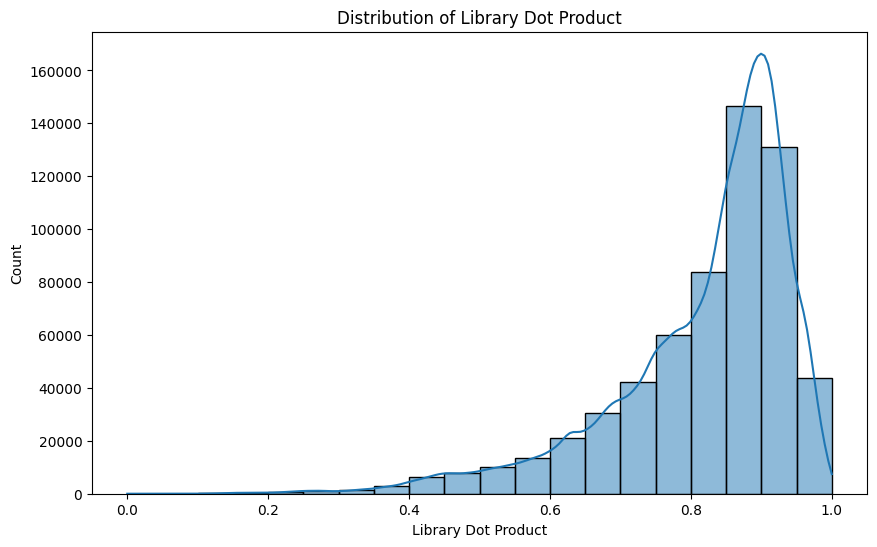

In [11]:
kdm.plot_library_dot_product_distribution(skyline_data)

In [12]:
skyline_clean = kdm.filter_library_dot_product(skyline_data, threshold=0.6)


In [13]:
# Summarise each peptide to count how many heavy or light signals are present in skyline_pivot
peptide_counts = kdm.summarise_peptide_counts(skyline_clean)


In [14]:
report_summary, peptide_list = kdm.report_peptide_protein_summary(peptide_counts)

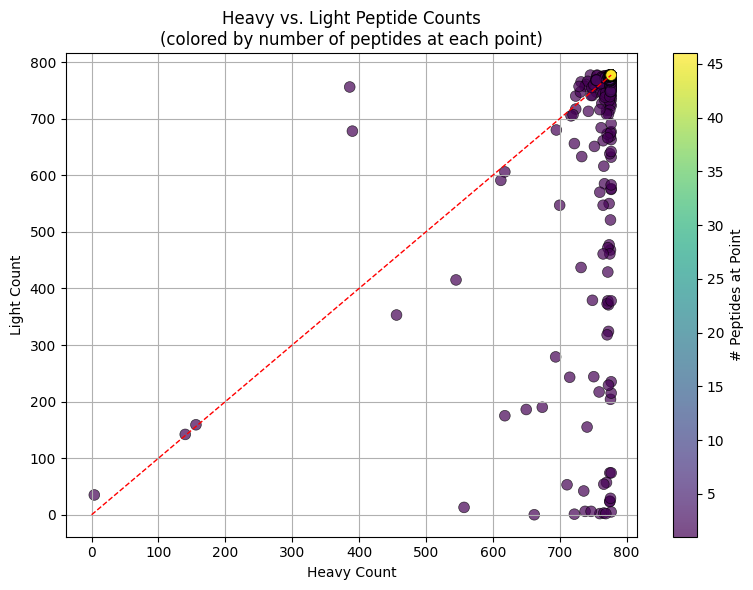

In [15]:
kdm.plot_heavy_light_scatter(peptide_counts)

In [16]:
filtered_peptide_counts = kdm.filter_peptide_counts(peptide_counts, light_cutoff=600, heavy_cutoff=600)

filtered_peptide_counts.head()


,Protein Name,Peptide,heavy_count,light_count
0,QR0140424_CKB|P12277,GTGGVDTAAVGGVFDVSNADR,777,632
1,QR0140840_SERPINA6|P08185,ITQDAQLK,724,717
2,QR0140840_SERPINA6|P08185,MNTVIAALSR,776,776
3,QR0140840_SERPINA6|P08185,WSAGLTSSQVDLYIPK,776,776
4,QR0221144_ADA2|Q9NZK5,DIPIEVCPISNQVLK,777,758


In [17]:
selected_peptides_report, selected_peptides = kdm.report_peptide_protein_summary(filtered_peptide_counts)

In [18]:
# from kardemumma.importer import MergeFiles

skyline_merge_obj = kdm.MergeFiles(skyline_data, sdrf_data_file, selected_peptides)
skyline_merge = skyline_merge_obj.merge_files()

Sample names in Skyline but not in SDRF:
  (none)
----------------------------------------
Sample names in SDRF but not in Skyline:
{'DIA_20260508_DA_4K_B3_Plate_10_A6.raw', 'PRM_20260410_DA_4K_B1_Plate1_G3.raw', 'PRM_20260410_DA_4K_B1_Plate1_C1.raw', 'PRM_20260410_DA_4K_B1_Plate1_A1.raw', 'DIA_20260508_DA_4K_B3_Plate_10_F3.raw', 'DIA_20260508_DA_4K_B3_Plate_10_F1.raw', 'PRM_20260508_DA_4K_B3_Plate_12_H5.raw', 'DIA_20260508_DA_4K_B3_Plate_10_H11.raw', 'PRM_20260508_DA_4K_B3_Plate_11_H3.raw', 'PRM_20260508_DA_4K_B3_Plate_11_C11.raw', 'DIA_20260508_DA_4K_B3_Plate_10_H7.raw', 'PRM_20260508_DA_4K_B3_Plate_12_E9.raw', 'DIA_20260508_DA_4K_B3_Plate_10_E6.raw', 'DIA_20260508_DA_4K_B3_Plate_10_E4.raw', 'PRM_20260508_DA_4K_B3_Plate_11_G4.raw', 'PRM_20260508_DA_4K_B3_Plate_12_C11.raw', 'PRM_20260410_DA_4K_B1_Plate1_D5.raw', 'PRM_20260508_DA_4K_B3_Plate_12_D4.raw', 'PRM_20260508_DA_4K_B3_Plate_12_D2.raw', 'PRM_20260410_DA_4K_B1_Plate1_F5.raw', 'PRM_20260508_DA_4K_B3_Plate_12_D5.raw', 'DIA_20260508

In [19]:
skyline_merge.head(20)

,Precursor,Replicate,File Name,Peptide Sequence,Peptide,Retention Time Calculator Score,Protein Name,Normalized Area,RatioLightToHeavy,Ratio Dot Product,Library Dot Product,Peptide Retention Time,Predicted Retention Time,Isotope Label Type,Precursor Charge,comment[data file],characteristics[Sample],characteristics[plate],factor value[disease]
0,488.2589++,PRM_20260410_DA_4K_B1_Plate1_F3,PRM_20260410_DA_4K_B1_Plate1_F3.raw,ISASAEELR,ISASAEELR,1,QR0260124_APOA4|P06727,7.1615E+6,0.5656,0.9761,0.9725,13.62,13.81,light,2,PRM_20260410_DA_4K_B1_Plate1_F3.raw,DA4K,Plate_1,Liver cancer
1,488.2589++,PRM_20260410_DA_4K_B1_Plate1_F7,PRM_20260410_DA_4K_B1_Plate1_F7.raw,ISASAEELR,ISASAEELR,1,QR0260124_APOA4|P06727,1.8050E+7,1.8261,0.9762,0.9731,13.75,13.81,light,2,PRM_20260410_DA_4K_B1_Plate1_F7.raw,DA4K,Plate_1,Stomach cancer
2,488.2589++,PRM_20260410_DA_4K_B1_Plate1_B12,PRM_20260410_DA_4K_B1_Plate1_B12.raw,ISASAEELR,ISASAEELR,1,QR0260124_APOA4|P06727,4.2532E+7,4.1650,0.9694,0.9601,13.58,13.81,light,2,PRM_20260410_DA_4K_B1_Plate1_B12.raw,DA4K,Plate_1,Nonalcoholic steatohepatitis
3,488.2589++,PRM_20260410_DA_4K_B1_Plate1_C9,PRM_20260410_DA_4K_B1_Plate1_C9.raw,ISASAEELR,ISASAEELR,1,QR0260124_APOA4|P06727,3.0742E+7,2.7133,0.9492,0.9549,13.71,13.81,light,2,PRM_20260410_DA_4K_B1_Plate1_C9.raw,DA4K,Plate_1,Coronary artery disease
4,488.2589++,PRM_20260410_DA_4K_B1_Plate1_E1,PRM_20260410_DA_4K_B1_Plate1_E1.raw,ISASAEELR,ISASAEELR,1,QR0260124_APOA4|P06727,4.3249E+7,1.2215,0.9946,0.9695,13.83,13.81,light,2,PRM_20260410_DA_4K_B1_Plate1_E1.raw,DA4K,Plate_1,Cerebral Venous Thrombosis
5,488.2589++,PRM_20260410_DA_4K_B1_Plate1_G1,PRM_20260410_DA_4K_B1_Plate1_G1.raw,ISASAEELR,ISASAEELR,1,QR0260124_APOA4|P06727,2.2592E+7,3.1195,0.9752,0.9772,13.84,13.81,light,2,PRM_20260410_DA_4K_B1_Plate1_G1.raw,DA4K,Plate_1,Nonalcoholic steatohepatitis
6,488.2589++,PRM_20260410_DA_4K_B1_Plate1_A12,PRM_20260410_DA_4K_B1_Plate1_A12.raw,ISASAEELR,ISASAEELR,1,QR0260124_APOA4|P06727,4.9012E+7,2.3907,0.9925,0.9682,13.65,13.81,light,2,PRM_20260410_DA_4K_B1_Plate1_A12.raw,DA4K,Plate_1,Cerebral Venous Thrombosis
7,488.2589++,PRM_20260410_DA_4K_B1_Plate1_F2,PRM_20260410_DA_4K_B1_Plate1_F2.raw,ISASAEELR,ISASAEELR,1,QR0260124_APOA4|P06727,1.3944E+7,2.9031,0.9422,0.9730,13.83,13.81,light,2,PRM_20260410_DA_4K_B1_Plate1_F2.raw,DA4K,Plate_1,Liver cancer
8,488.2589++,PRM_20260410_DA_4K_B1_Plate1_C3,PRM_20260410_DA_4K_B1_Plate1_C3.raw,ISASAEELR,ISASAEELR,1,QR0260124_APOA4|P06727,1.7900E+7,1.0019,0.9811,0.9891,13.74,13.81,light,2,PRM_20260410_DA_4K_B1_Plate1_C3.raw,DA4K,Plate_1,Type 2 diabetes
9,488.2589++,PRM_20260410_DA_4K_B1_Plate1_F9,PRM_20260410_DA_4K_B1_Plate1_F9.raw,ISASAEELR,ISASAEELR,1,QR0260124_APOA4|P06727,3.2866E+7,2.4344,0.9612,0.9835,13.84,13.81,light,2,PRM_20260410_DA_4K_B1_Plate1_F9.raw,DA4K,Plate_1,Longevity


In [20]:
skyline_pool = skyline_merge_obj.select_pool_data(col_sample='characteristics[Sample]', sample_value='PlasmaPool')
# Need to check printing????

Summary of samples per plate:
Plate Plate_2: 5 unique comment[data file] names
Plate Plate_3: 5 unique comment[data file] names
Plate Plate_4: 5 unique comment[data file] names
Plate Plate_5: 5 unique comment[data file] names
Plate Plate_6: 5 unique comment[data file] names
Plate Plate_7: 5 unique comment[data file] names
Plate Plate_8: 5 unique comment[data file] names
Plate Plate_9: 5 unique comment[data file] names


In [21]:
skyline_pool.head()

,Precursor,Replicate,File Name,Peptide Sequence,Peptide,Retention Time Calculator Score,Protein Name,Normalized Area,RatioLightToHeavy,Ratio Dot Product,Library Dot Product,Peptide Retention Time,Predicted Retention Time,Isotope Label Type,Precursor Charge,comment[data file],characteristics[Sample],characteristics[plate],factor value[disease]
0,741.3798++ (heavy),PRM_20260410_DA_4K_B1_Plate2_A9,PRM_20260410_DA_4K_B1_Plate2_A9.raw,AAVYHHFISDGVR,AAVYHHFISDGVR,1,QR0280090_C3|P01024,4.0183E+6,0.7428,NaN,0.8191,14.18,14.17,heavy,2,PRM_20260410_DA_4K_B1_Plate2_A9.raw,PlasmaPool,Plate_2,PlasmaPool
1,736.3757++,PRM_20260410_DA_4K_B1_Plate2_A9,PRM_20260410_DA_4K_B1_Plate2_A9.raw,AAVYHHFISDGVR,AAVYHHFISDGVR,1,QR0280090_C3|P01024,4.0183E+6,0.7428,0.9627,0.8165,14.18,14.17,light,2,PRM_20260410_DA_4K_B1_Plate2_A9.raw,PlasmaPool,Plate_2,PlasmaPool
2,539.9587+++ (heavy),PRM_20260410_DA_4K_B1_Plate2_A9,PRM_20260410_DA_4K_B1_Plate2_A9.raw,AAVYHHFISDGVRK,AAVYHHFISDGVRK,1,QR0280090_C3|P01024,6.1058E+6,0.5814,NaN,0.7320,13.04,12.97,heavy,3,PRM_20260410_DA_4K_B1_Plate2_A9.raw,PlasmaPool,Plate_2,PlasmaPool
3,533.9512+++,PRM_20260410_DA_4K_B1_Plate2_A9,PRM_20260410_DA_4K_B1_Plate2_A9.raw,AAVYHHFISDGVRK,AAVYHHFISDGVRK,1,QR0280090_C3|P01024,6.1058E+6,0.5814,0.8780,0.6403,13.04,12.97,light,3,PRM_20260410_DA_4K_B1_Plate2_A9.raw,PlasmaPool,Plate_2,PlasmaPool
4,664.8145++ (heavy),PRM_20260410_DA_4K_B1_Plate2_A9,PRM_20260410_DA_4K_B1_Plate2_A9.raw,ACIPTGPYPCGK,ACIPTGPYPCGK,1,QR3730418_F10|P00742,1.7251E+6,0.6103,NaN,0.9036,16.01,16.09,heavy,2,PRM_20260410_DA_4K_B1_Plate2_A9.raw,PlasmaPool,Plate_2,PlasmaPool


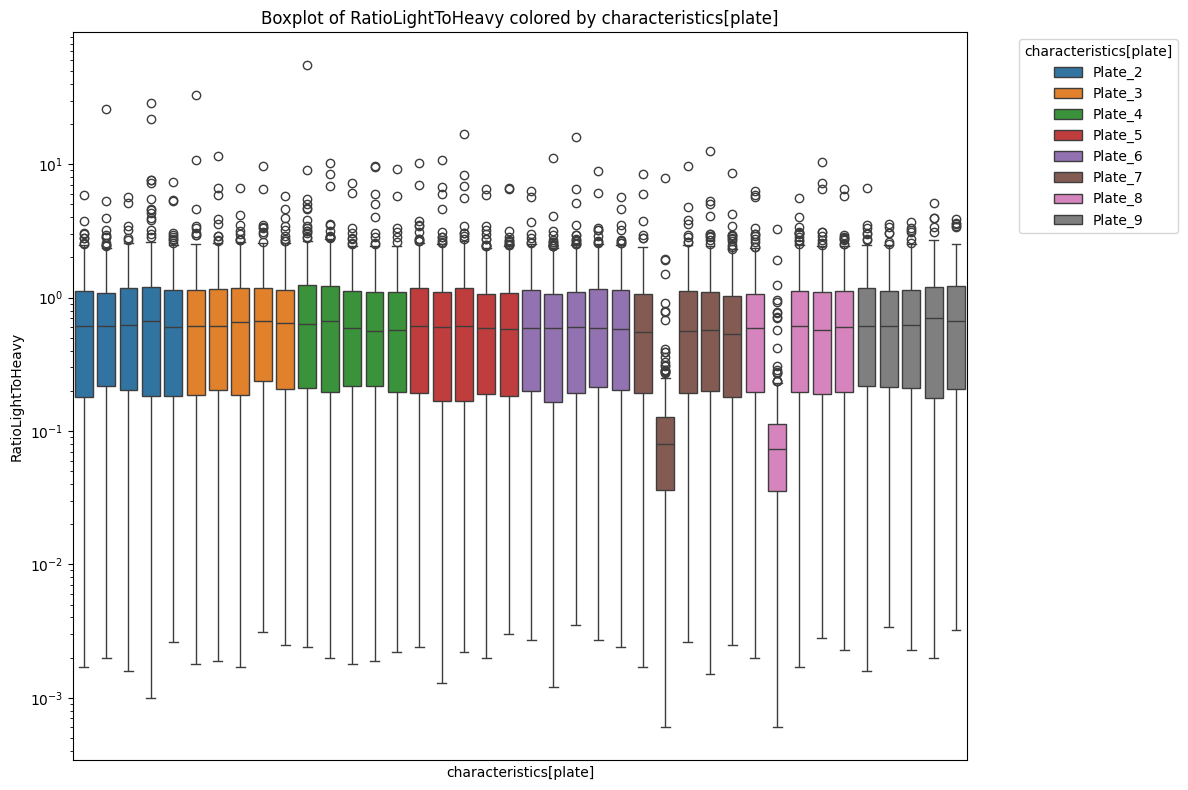

In [22]:
# Plot log_ratio of each sample in boxplot, colored by plate, but x-axis is Replicate, sorted by plate (though x labels are hidden).
kdm.plot_pool_boxplot(skyline_pool)


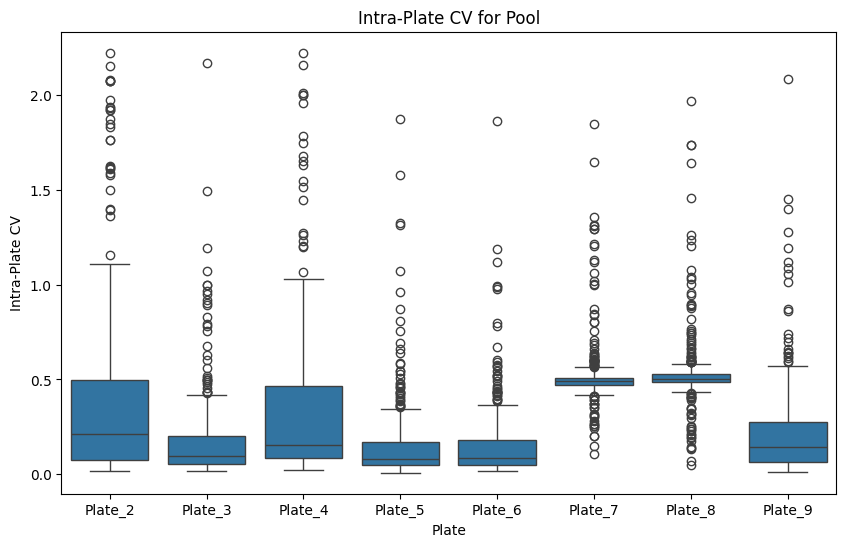

In [23]:
# Calculate intra-plate CV

peptide_plate_stats = kdm.calculate_intra_plate_cv(skyline_pool, col_name='characteristics[plate]')
kdm.plot_intra_plate_cv_stats(peptide_plate_stats, col_name='characteristics[plate]')

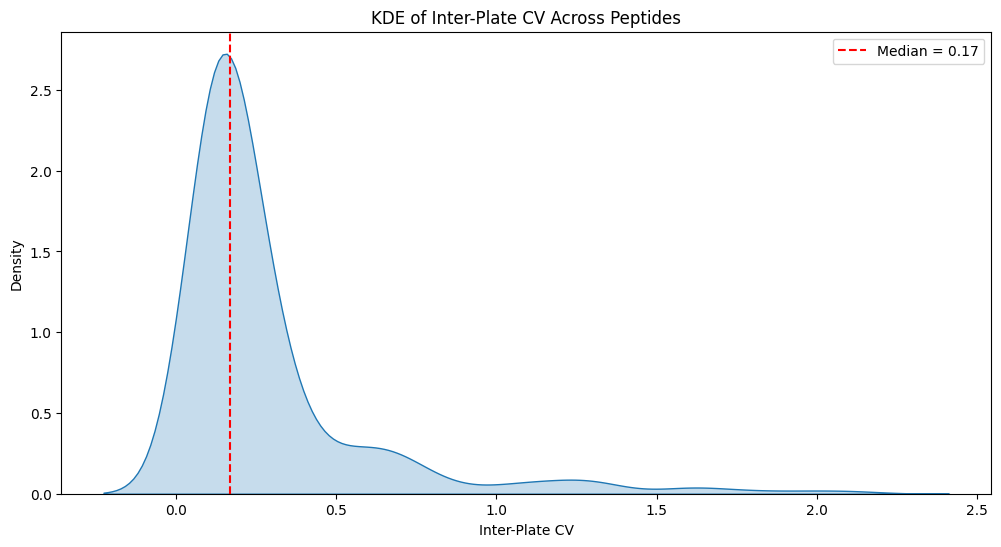

In [24]:
interplate_cv = kdm.calculate_inter_plate_cv(peptide_plate_stats)
kdm.plot_inter_plate_cv_kde(interplate_cv)

In [25]:
interplate_cv.head()

,Peptide Sequence,grand_mean,between_plate_sd,inter_plate_cv
0,TNFDNDIALVR,1.103470,0.083860,0.075996
1,GLPNVVTSAISLPNIR,0.353280,0.027833,0.078784
2,HYEGSTVPEK,1.510722,0.124138,0.082171
3,HLEVDVWVIEPQGLR,1.200745,0.101005,0.084119
4,ALVQQMEQLR,1.468900,0.125943,0.085740


In [26]:
# Print interplate_cv froom low to high
print('This is the interplate_cv from low to high:')
print(interplate_cv[interplate_cv['inter_plate_cv'] < 0.1])

This is the interplate_cv from low to high:
        Peptide Sequence  grand_mean  between_plate_sd  inter_plate_cv
0            TNFDNDIALVR    1.103470          0.083860        0.075996
1       GLPNVVTSAISLPNIR    0.353280          0.027833        0.078784
2             HYEGSTVPEK    1.510722          0.124138        0.082171
3        HLEVDVWVIEPQGLR    1.200745          0.101005        0.084119
4             ALVQQMEQLR    1.468900          0.125943        0.085740
5               ITQDAQLK    0.904875          0.078136        0.086350
6              GYTLADNGK    0.481295          0.043181        0.089719
7      QLKEHAVEGDCDFQLLK    1.432783          0.128595        0.089752
8        SLTLGIEPVSPTSLR    0.498152          0.044783        0.089898
9         VTLNGVPAQPLGPR    0.026998          0.002460        0.091102
10        VCPFAGILENGAVR    1.253545          0.116788        0.093166
11              GLLSGWAR    0.085870          0.008077        0.094064
12       FICPLTGLWPINTLK    1.472

Total peptides: 321
  CV < 10%: 24 peptides
  CV < 20%: 194 peptides


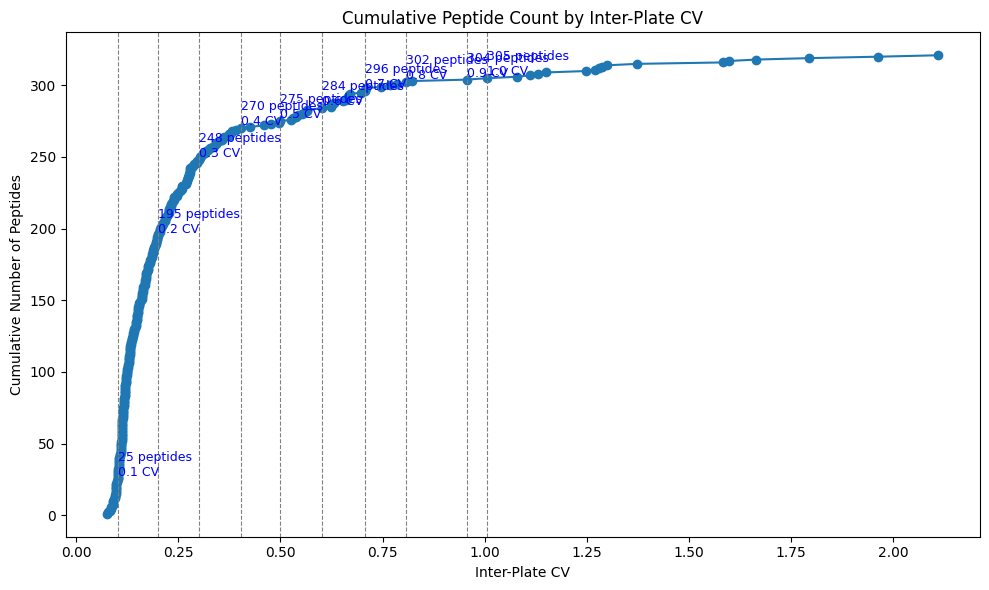

In [27]:
kdm.plot_cumulative_peptide_count_by_cv(interplate_cv)

In [28]:
selected_peptides = kdm.get_lowest_cv_peptides(interplate_cv, 10)
selected_peptides

array(['TNFDNDIALVR', 'GLPNVVTSAISLPNIR', 'HYEGSTVPEK', 'HLEVDVWVIEPQGLR',
       'ALVQQMEQLR', 'ITQDAQLK', 'GYTLADNGK', 'QLKEHAVEGDCDFQLLK',
       'SLTLGIEPVSPTSLR', 'VTLNGVPAQPLGPR', 'VCPFAGILENGAVR', 'GLLSGWAR',
       'FICPLTGLWPINTLK', 'FSIEGSYQLEK', 'HGNTDSEGIVEVK',
       'FLHVPDTFEGHFDGVPVISK', 'VQFELHYQEVK', 'NGVAQEPVHLDSPAIK',
       'VNSFFSTFK', 'AFLLTPR', 'ESDTSYVSLK', 'IYLQPGR', 'TGYYFDGISR',
       'DPTFIPAPIQAK'], dtype=object)

In [29]:
# Batch/Plate adjustment, correcting for each peptide within each plate (batch) 
# using only peptides in the top 10% lowest inter-plate CV for normalization

pool_selected_df = skyline_pool[skyline_pool['Peptide Sequence'].isin(selected_peptides)]

# Remove bad plasmapool 

bad_pools = [
       'PRM_20260422_DA_4K_B2_Plate_7_C1.raw',
       'PRM_20260422_DA_4K_B2_Plate_8_B8.raw']


# Remove bad peptides 
bad_peptides = ['ESDTSYVSLK', 'VTLNGVPAQPLGPR', 'FSIEGSYQLEK', 'GLLSGWAR']

# Filter bad_pools from pool_selected_df
pool_selected_df = pool_selected_df[~pool_selected_df['File Name'].isin(bad_pools)]

# Filter bad_peptides from pool_selected_df
pool_selected_df = pool_selected_df[~pool_selected_df['Peptide Sequence'].isin(bad_peptides)]

# Filter pool_data to include only those peptides for normalization calculation
pool_selected_df

,Precursor,Replicate,File Name,Peptide Sequence,Peptide,Retention Time Calculator Score,Protein Name,Normalized Area,RatioLightToHeavy,Ratio Dot Product,Library Dot Product,Peptide Retention Time,Predicted Retention Time,Isotope Label Type,Precursor Charge,comment[data file],characteristics[Sample],characteristics[plate],factor value[disease]
10,414.2543++ (heavy),PRM_20260410_DA_4K_B1_Plate2_A9,PRM_20260410_DA_4K_B1_Plate2_A9.raw,AFLLTPR,AFLLTPR,1,QR3340379_APOM|O95445,9.4880E+6,1.0532,NaN,0.9677,19.32,19.13,heavy,2,PRM_20260410_DA_4K_B1_Plate2_A9.raw,PlasmaPool,Plate_2,PlasmaPool
11,409.2502++,PRM_20260410_DA_4K_B1_Plate2_A9,PRM_20260410_DA_4K_B1_Plate2_A9.raw,AFLLTPR,AFLLTPR,1,QR3340379_APOM|O95445,9.4880E+6,1.0532,0.9838,0.9573,19.32,19.13,light,2,PRM_20260410_DA_4K_B1_Plate2_A9.raw,PlasmaPool,Plate_2,PlasmaPool
32,613.3335++ (heavy),PRM_20260410_DA_4K_B1_Plate2_A9,PRM_20260410_DA_4K_B1_Plate2_A9.raw,ALVQQMEQLR,ALVQQMEQLR,1,QR0260124_APOA4|P06727,8.7301E+7,1.5889,NaN,0.8638,19.02,18.90,heavy,2,PRM_20260410_DA_4K_B1_Plate2_A9.raw,PlasmaPool,Plate_2,PlasmaPool
33,608.3293++,PRM_20260410_DA_4K_B1_Plate2_A9,PRM_20260410_DA_4K_B1_Plate2_A9.raw,ALVQQMEQLR,ALVQQMEQLR,1,QR0260124_APOA4|P06727,8.7301E+7,1.5889,0.9504,0.8776,19.02,18.90,light,2,PRM_20260410_DA_4K_B1_Plate2_A9.raw,PlasmaPool,Plate_2,PlasmaPool
70,653.3683++ (heavy),PRM_20260410_DA_4K_B1_Plate2_A9,PRM_20260410_DA_4K_B1_Plate2_A9.raw,DPTFIPAPIQAK,DPTFIPAPIQAK,1,QR0350062_AGT|P01019,8.3100E+6,0.9812,NaN,0.8684,21.06,20.99,heavy,2,PRM_20260410_DA_4K_B1_Plate2_A9.raw,PlasmaPool,Plate_2,PlasmaPool
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25573,751.8928++,PRM_20260508_DA_4K_B3_Plate_9_E5,PRM_20260508_DA_4K_B3_Plate_9_E5.raw,VCPFAGILENGAVR,VCPFAGILENGAVR,1,QR5000011_APOH|P02749,1.8163E+8,1.3057,0.9804,0.8308,24.11,23.75,light,2,PRM_20260508_DA_4K_B3_Plate_9_E5.raw,PlasmaPool,Plate_9,PlasmaPool
25602,542.7813++ (heavy),PRM_20260508_DA_4K_B3_Plate_9_E5,PRM_20260508_DA_4K_B3_Plate_9_E5.raw,VNSFFSTFK,VNSFFSTFK,1,QR0260124_APOA4|P06727,5.9958E+6,1.1692,NaN,0.8500,21.71,21.44,heavy,2,PRM_20260508_DA_4K_B3_Plate_9_E5.raw,PlasmaPool,Plate_9,PlasmaPool
25603,538.7742++,PRM_20260508_DA_4K_B3_Plate_9_E5,PRM_20260508_DA_4K_B3_Plate_9_E5.raw,VNSFFSTFK,VNSFFSTFK,1,QR0260124_APOA4|P06727,5.9958E+6,1.1692,0.9224,0.9231,21.71,21.44,light,2,PRM_20260508_DA_4K_B3_Plate_9_E5.raw,PlasmaPool,Plate_9,PlasmaPool
25606,476.5851+++ (heavy),PRM_20260508_DA_4K_B3_Plate_9_E5,PRM_20260508_DA_4K_B3_Plate_9_E5.raw,VQFELHYQEVK,VQFELHYQEVK,1,QR3760404_ITIH2|P19823,2.7581E+6,1.4990,NaN,0.7380,17.58,17.31,heavy,3,PRM_20260508_DA_4K_B3_Plate_9_E5.raw,PlasmaPool,Plate_9,PlasmaPool


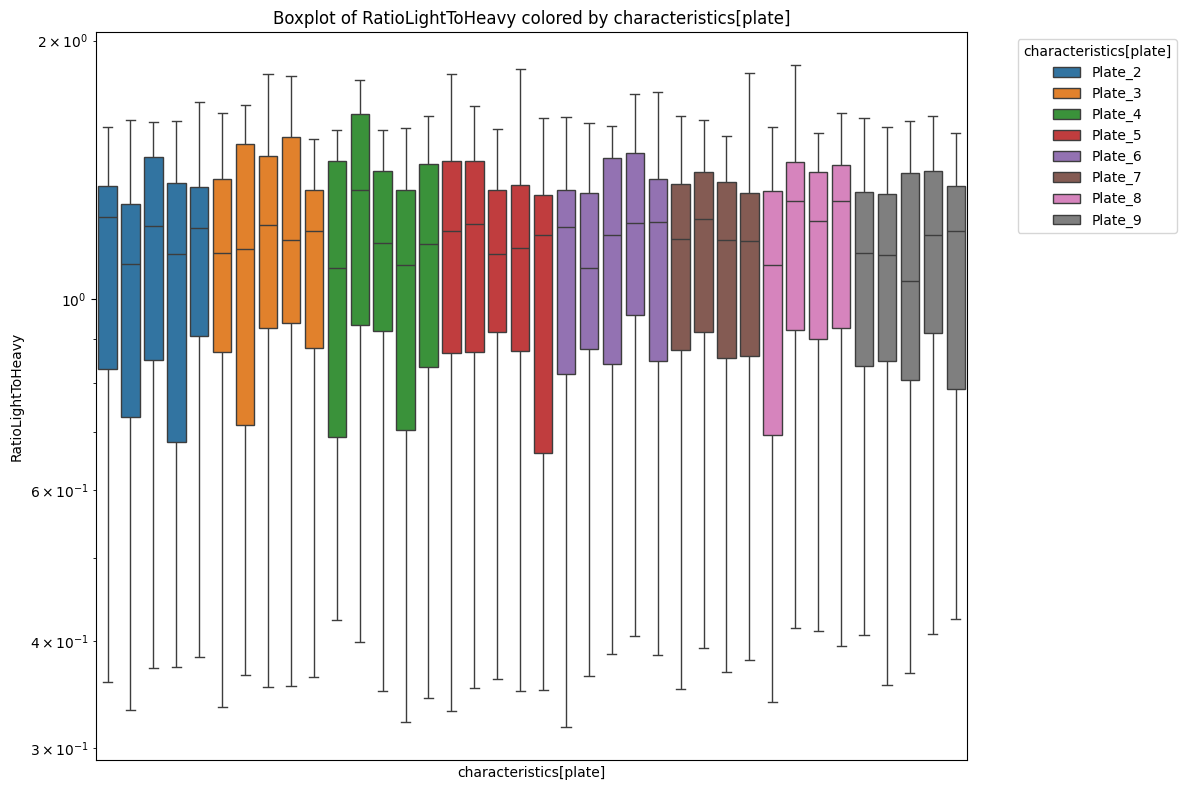

In [30]:
kdm.plot_pool_boxplot(pool_selected_df)

In [31]:
plate_factor_table, conversion_factors, model = kdm.get_plate_conversion_factors(pool_selected_df, col_plate='characteristics[plate]', log_transform=True  )

Conversion factors: {'Plate_2': 0.9410155805872489, 'Plate_3': 1.0463607213734605, 'Plate_4': 1.188929592232373, 'Plate_5': 0.9994454634262865, 'Plate_6': 1.0670129018347652, 'Plate_7': 0.9981351388620863, 'Plate_8': 0.8795432256089242, 'Plate_9': 1.124302446721552}


In [32]:
plate_factor_table

,characteristics[plate],plate_median,correction_factor
0,Plate_2,0.169475,0.941016
1,Plate_3,0.152413,1.046361
2,Plate_4,0.134136,1.188930
3,Plate_5,0.159567,0.999445
4,Plate_6,0.149463,1.067013
5,Plate_7,0.159777,0.998135
6,Plate_8,0.181320,0.879543
7,Plate_9,0.141847,1.124302


In [33]:
conversion_factors

{'Plate_2': 0.9410155805872489,
 'Plate_3': 1.0463607213734605,
 'Plate_4': 1.188929592232373,
 'Plate_5': 0.9994454634262865,
 'Plate_6': 1.0670129018347652,
 'Plate_7': 0.9981351388620863,
 'Plate_8': 0.8795432256089242,
 'Plate_9': 1.124302446721552}

/home/thanadol/Documents/GitHub/kardemumma/src/kardemumma/prm.py:469: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plot_df["Peptide Sequence"] = pd.Categorical(


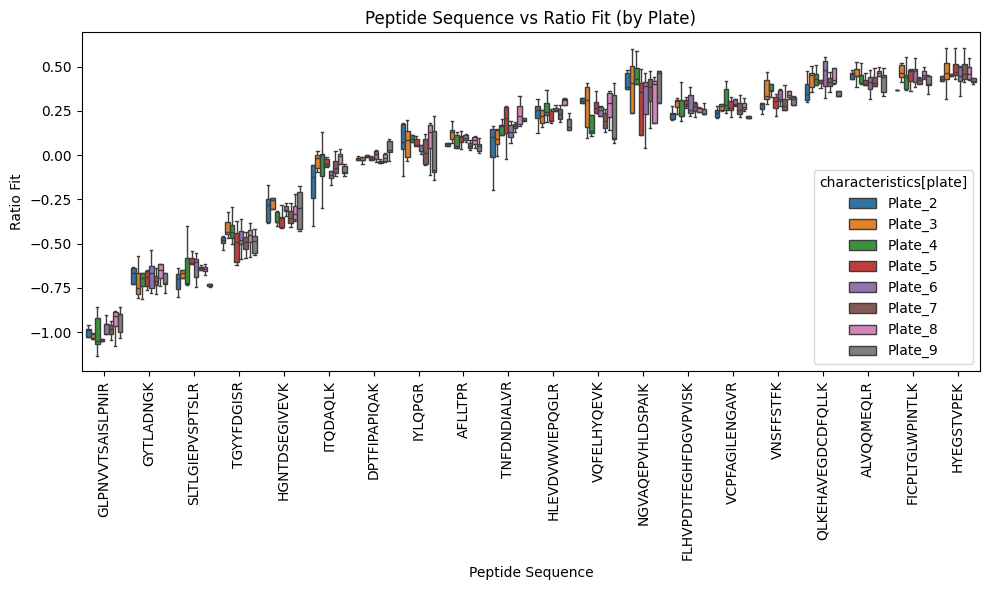

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [34]:
kdm.plot_plate_conversion_factors(pool_selected_df, col_plate='characteristics[plate]', log_transform=True  )

In [35]:
# Use the adjust_ratio_by_plate function above to add RatioLightToHeavy_adj to skyline_merge
# First, construct a Plate column of the correct type for the function
skyline_merge_adj = skyline_merge.copy()
# Remove samples from Replicate column that are in qc_samples
skyline_merge_adj = skyline_merge_adj[~skyline_merge_adj['Replicate'].isin(qc_samples)]

# Remove sampels from Plate_1 from characteristics[plate]
skyline_merge_adj = skyline_merge_adj[skyline_merge_adj['characteristics[plate]'] != 'Plate_1']


In [36]:
# Adjust ratio by conversion factor 
skyline_merge_adj = kdm.adjust_ratio_by_plate(skyline_merge_adj, conversion_factors)

skyline_merge_adj.head()

,Precursor,Replicate,File Name,Peptide Sequence,Peptide,Retention Time Calculator Score,Protein Name,Normalized Area,RatioLightToHeavy,Ratio Dot Product,Library Dot Product,Peptide Retention Time,Predicted Retention Time,Isotope Label Type,Precursor Charge,comment[data file],characteristics[Sample],characteristics[plate],factor value[disease]
10,488.2589++,PRM_20260410_DA_4K_B1_Plate2_A12,PRM_20260410_DA_4K_B1_Plate2_A12.raw,ISASAEELR,ISASAEELR,1,QR0260124_APOA4|P06727,3.0780E+7,2.415475,0.9865,0.9711,13.74,13.81,light,2,PRM_20260410_DA_4K_B1_Plate2_A12.raw,DA4K,Plate_2,Schizophrenia
11,488.2589++,PRM_20260410_DA_4K_B1_Plate2_A6,PRM_20260410_DA_4K_B1_Plate2_A6.raw,ISASAEELR,ISASAEELR,1,QR0260124_APOA4|P06727,2.8433E+7,2.184023,0.9808,0.9746,13.79,13.81,light,2,PRM_20260410_DA_4K_B1_Plate2_A6.raw,DA4K,Plate_2,Nonalcoholic steatohepatitis
12,488.2589++,PRM_20260410_DA_4K_B1_Plate2_A1,PRM_20260410_DA_4K_B1_Plate2_A1.raw,ISASAEELR,ISASAEELR,1,QR0260124_APOA4|P06727,1.4979E+7,0.934416,0.9858,0.9648,13.69,13.81,light,2,PRM_20260410_DA_4K_B1_Plate2_A1.raw,DA4K,Plate_2,Cerebral Venous Thrombosis
13,488.2589++,PRM_20260410_DA_4K_B1_Plate2_E2,PRM_20260410_DA_4K_B1_Plate2_E2.raw,ISASAEELR,ISASAEELR,1,QR0260124_APOA4|P06727,1.9535E+7,1.448541,0.9722,0.9815,13.67,13.81,light,2,PRM_20260410_DA_4K_B1_Plate2_E2.raw,DA4K,Plate_2,Cervical Cancer
14,488.2589++,PRM_20260410_DA_4K_B1_Plate2_C3,PRM_20260410_DA_4K_B1_Plate2_C3.raw,ISASAEELR,ISASAEELR,1,QR0260124_APOA4|P06727,6.0298E+7,3.889415,0.9913,0.9811,13.75,13.81,light,2,PRM_20260410_DA_4K_B1_Plate2_C3.raw,DA4K,Plate_2,Type 2 diabetes


In [37]:
# From skyline_merge_adj, filter to pool samples
pool_data_adj = skyline_merge_adj[skyline_merge_adj['characteristics[Sample]'] != 'PlasmaPool'].copy()

# Reorder by characteristics[Plate]
pool_data_adj = pool_data_adj.sort_values(by='characteristics[plate]')

pool_data_adj.head()


,Precursor,Replicate,File Name,Peptide Sequence,Peptide,Retention Time Calculator Score,Protein Name,Normalized Area,RatioLightToHeavy,Ratio Dot Product,Library Dot Product,Peptide Retention Time,Predicted Retention Time,Isotope Label Type,Precursor Charge,comment[data file],characteristics[Sample],characteristics[plate],factor value[disease]
10,488.2589++,PRM_20260410_DA_4K_B1_Plate2_A12,PRM_20260410_DA_4K_B1_Plate2_A12.raw,ISASAEELR,ISASAEELR,1,QR0260124_APOA4|P06727,3.0780E+7,2.415475,0.9865,0.9711,13.74,13.81,light,2,PRM_20260410_DA_4K_B1_Plate2_A12.raw,DA4K,Plate_2,Schizophrenia
225383,475.2243++,PRM_20260410_DA_4K_B1_Plate2_F12,PRM_20260410_DA_4K_B1_Plate2_F12.raw,FTFEYSR,FTFEYSR,1,QR0670086_AFM|P43652,6.6402E+6,0.487558,0.9063,0.9592,17.93,17.99,light,2,PRM_20260410_DA_4K_B1_Plate2_F12.raw,DA4K,Plate_2,Longevity
225382,475.2243++,PRM_20260410_DA_4K_B1_Plate2_G7,PRM_20260410_DA_4K_B1_Plate2_G7.raw,FTFEYSR,FTFEYSR,1,QR0670086_AFM|P43652,1.0262E+7,1.019431,0.9444,0.9701,17.63,17.99,light,2,PRM_20260410_DA_4K_B1_Plate2_G7.raw,DA4K,Plate_2,Multiple sclerosis
225381,475.2243++,PRM_20260410_DA_4K_B1_Plate2_D8,PRM_20260410_DA_4K_B1_Plate2_D8.raw,FTFEYSR,FTFEYSR,1,QR0670086_AFM|P43652,8.2034E+6,0.543243,0.9154,0.9624,17.82,17.99,light,2,PRM_20260410_DA_4K_B1_Plate2_D8.raw,DA4K,Plate_2,Type 2 diabetes
225380,475.2243++,PRM_20260410_DA_4K_B1_Plate2_D1,PRM_20260410_DA_4K_B1_Plate2_D1.raw,FTFEYSR,FTFEYSR,1,QR0670086_AFM|P43652,2.4562E+6,0.275872,0.8732,0.8949,16.97,17.99,light,2,PRM_20260410_DA_4K_B1_Plate2_D1.raw,DA4K,Plate_2,Type 2 diabetes


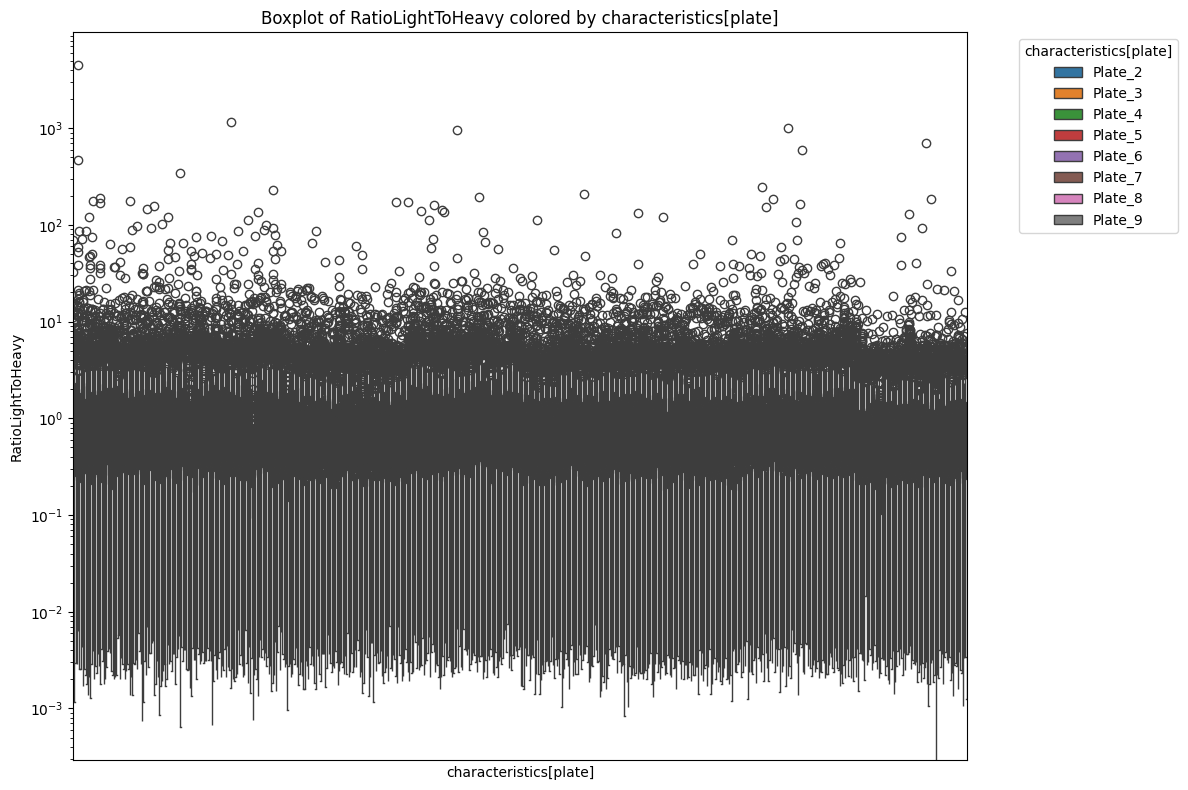

In [38]:
kdm.plot_pool_boxplot(pool_data_adj)

/home/thanadol/Documents/GitHub/kardemumma/src/kardemumma/prm.py:469: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plot_df["Peptide Sequence"] = pd.Categorical(


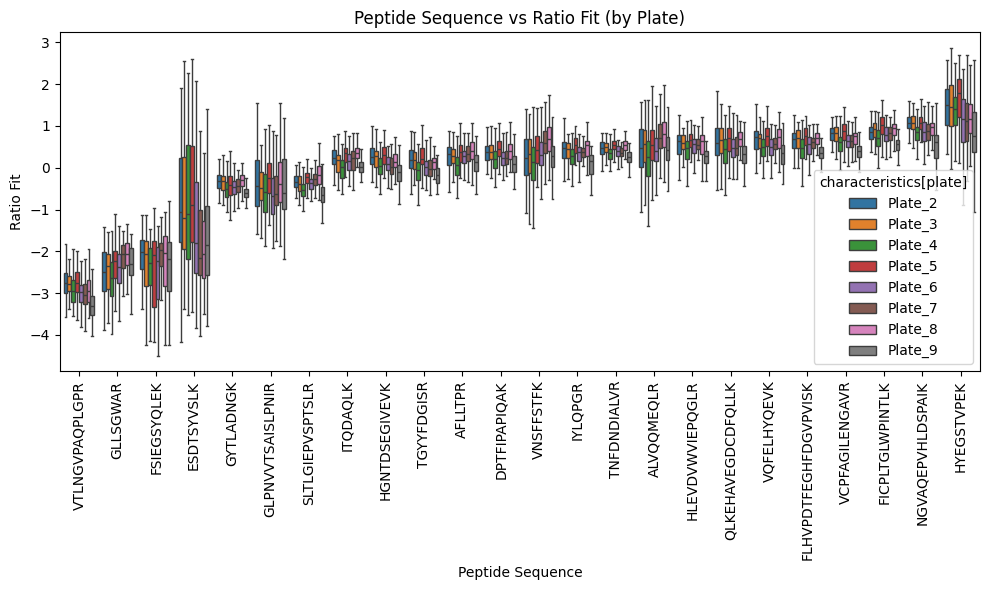

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [39]:
pool_selected_adj = pool_data_adj[pool_data_adj['Peptide Sequence'].isin(selected_peptides)]

kdm.plot_plate_conversion_factors(pool_selected_adj, col_plate='characteristics[plate]', log_transform=True  )

# SDRF metadata

Overview of metadata

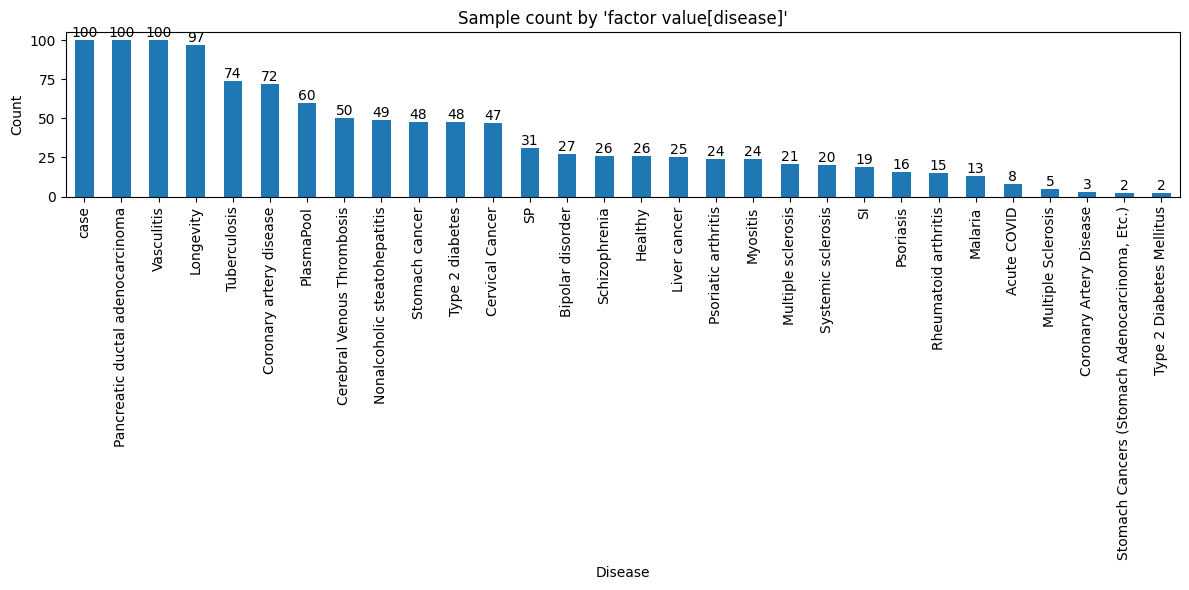

In [40]:
import matplotlib.pyplot as plt

# Make a barplot of 'factor value[disease]' column
plt.figure(figsize=(12,6))
value_counts = sdrf_data_file['factor value[disease]'].value_counts()
ax = value_counts.plot(kind='bar')
plt.xlabel('Disease')
plt.ylabel('Count')
plt.title("Sample count by 'factor value[disease]'")
plt.tight_layout()

# Add number on top of each bar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2, p.get_height()), 
                ha='center', va='bottom', fontsize=10)

plt.show()

# Calculate absolute quantification

In [41]:
# kdm.validate_sdrf(sdrf_path)

# Need to fix this 

In [42]:
qreps_lot = sdrf_data.extract_qreps_lot_number()
print(qreps_lot)

qREPs lot number: 24001
24001


In [43]:
# Extract qRePS lot from SDRF file 
qreps_lot = sdrf_data.extract_qreps_lot_number()
# Fetch qRePS table
qreps_table = kdm.fetch_qreps_table(qreps_lot)

qreps_table.head()


qREPs lot number: 24001


,qRePS,Gene,Protein,Uniprot,Amount per well [pmol]
0,QR3140513,A1BG,Alpha-1B-glycoprotein,P04217,1.327
1,QR5000096,A2M,Alpha-2-macroglobulin,P01023,1.971
2,QR0140749,ACTN1,Alpha-actinin-1,P12814,0.157
3,QR0221144,ADA2,Adenosine deaminase 2,Q9NZK5,0.015
4,QR5000237,ADAMTS13,A disintegrin and metalloproteinase with throm...,Q76LX8,0.057


In [ ]:
# plot_peptide_concentration_by_group is defined in the cell below (after abs_df)


In [44]:
skyline_merge_adj.head()

,Precursor,Replicate,File Name,Peptide Sequence,Peptide,Retention Time Calculator Score,Protein Name,Normalized Area,RatioLightToHeavy,Ratio Dot Product,Library Dot Product,Peptide Retention Time,Predicted Retention Time,Isotope Label Type,Precursor Charge,comment[data file],characteristics[Sample],characteristics[plate],factor value[disease]
10,488.2589++,PRM_20260410_DA_4K_B1_Plate2_A12,PRM_20260410_DA_4K_B1_Plate2_A12.raw,ISASAEELR,ISASAEELR,1,QR0260124_APOA4|P06727,3.0780E+7,2.415475,0.9865,0.9711,13.74,13.81,light,2,PRM_20260410_DA_4K_B1_Plate2_A12.raw,DA4K,Plate_2,Schizophrenia
11,488.2589++,PRM_20260410_DA_4K_B1_Plate2_A6,PRM_20260410_DA_4K_B1_Plate2_A6.raw,ISASAEELR,ISASAEELR,1,QR0260124_APOA4|P06727,2.8433E+7,2.184023,0.9808,0.9746,13.79,13.81,light,2,PRM_20260410_DA_4K_B1_Plate2_A6.raw,DA4K,Plate_2,Nonalcoholic steatohepatitis
12,488.2589++,PRM_20260410_DA_4K_B1_Plate2_A1,PRM_20260410_DA_4K_B1_Plate2_A1.raw,ISASAEELR,ISASAEELR,1,QR0260124_APOA4|P06727,1.4979E+7,0.934416,0.9858,0.9648,13.69,13.81,light,2,PRM_20260410_DA_4K_B1_Plate2_A1.raw,DA4K,Plate_2,Cerebral Venous Thrombosis
13,488.2589++,PRM_20260410_DA_4K_B1_Plate2_E2,PRM_20260410_DA_4K_B1_Plate2_E2.raw,ISASAEELR,ISASAEELR,1,QR0260124_APOA4|P06727,1.9535E+7,1.448541,0.9722,0.9815,13.67,13.81,light,2,PRM_20260410_DA_4K_B1_Plate2_E2.raw,DA4K,Plate_2,Cervical Cancer
14,488.2589++,PRM_20260410_DA_4K_B1_Plate2_C3,PRM_20260410_DA_4K_B1_Plate2_C3.raw,ISASAEELR,ISASAEELR,1,QR0260124_APOA4|P06727,6.0298E+7,3.889415,0.9913,0.9811,13.75,13.81,light,2,PRM_20260410_DA_4K_B1_Plate2_C3.raw,DA4K,Plate_2,Type 2 diabetes


In [45]:
# Calculate absolute protein concentration
abs_df = kdm.get_absolute_conc(qreps_table, skyline_merge_adj)



Number of unique qRePS ids: 156
Number of unique Peptide Sequences: 321
Number of unique Protein Names: 156
Number of unique Replicates: 767


In [46]:
# Print out the table
abs_df.head()

Replicate                                                  PRM_20260410_DA_4K_B1_Plate2_A1  \
qRePS     Peptide Sequence      Protein Name                                                 
QR0140424 GTGGVDTAAVGGVFDVSNADR QR0140424_CKB|P12277                                0.0070   
QR0140840 ITQDAQLK              QR0140840_SERPINA6|P08185                           0.3968   
          MNTVIAALSR            QR0140840_SERPINA6|P08185                           0.2096   
          WSAGLTSSQVDLYIPK      QR0140840_SERPINA6|P08185                           0.3051   
QR0221144 DIPIEVCPISNQVLK       QR0221144_ADA2|Q9NZK5                               0.0015   

Replicate                                                  PRM_20260410_DA_4K_B1_Plate2_A10  \
qRePS     Peptide Sequence      Protein Name                                                  
QR0140424 GTGGVDTAAVGGVFDVSNADR QR0140424_CKB|P12277                                 0.0030   
QR0140840 ITQDAQLK              QR0140840_SERPINA6|P08185                            0.0013   
          MNTVIAALSR            QR0140840_SERPINA6|P08185                            0.2547   
          WSAGLTSSQVDLYIPK      QR0140840_SERPINA6|P08185                            0.5201   
QR0221144 DIPIEVCPISNQVLK       QR0221144_ADA2|Q9NZK5                                0.0020   

Replicate                                                  PRM_20260410_DA_4K_B1_Plate2_A11  \
qRePS     Peptide Sequence      Protein Name                                                  
QR0140424 GTGGVDTAAVGGVFDVSNADR QR0140424_CKB|P12277                                 0.0033   
QR0140840 ITQDAQLK              QR0140840_SERPINA6|P08185                            0.2352   
          MNTVIAALSR            QR0140840_SERPINA6|P08185                            0.1208   
          WSAGLTSSQVDLYIPK      QR0140840_SERPINA6|P08185                            0.2087   
QR0221144 DIPIEVCPISNQVLK       QR0221144_ADA2|Q9NZK5                                0.0004   

Replicate                                                  PRM_20260410_DA_4K_B1_Plate2_A12  \
qRePS     Peptide Sequence      Protein Name                                                  
QR0140424 GTGGVDTAAVGGVFDVSNADR QR0140424_CKB|P12277                                 0.0060   
QR0140840 ITQDAQLK              QR0140840_SERPINA6|P08185                            0.4898   
          MNTVIAALSR            QR0140840_SERPINA6|P08185                            0.2830   
          WSAGLTSSQVDLYIPK      QR0140840_SERPINA6|P08185                            0.6016   
QR0221144 DIPIEVCPISNQVLK       QR0221144_ADA2|Q9NZK5                                0.0014   

Replicate                                                  PRM_20260410_DA_4K_B1_Plate2_A2  \
qRePS     Peptide Sequence      Protein Name                                                 
QR0140424 GTGGVDTAAVGGVFDVSNADR QR0140424_CKB|P12277                                0.0144   
QR0140840 ITQDAQLK              QR0140840_SERPINA6|P08185                           0.4764   
          MNTVIAALSR            QR0140840_SERPINA6|P08185                           0.1885   
          WSAGLTSSQVDLYIPK      QR0140840_SERPINA6|P08185                           0.2808   
QR0221144 DIPIEVCPISNQVLK       QR0221144_ADA2|Q9NZK5                               0.0010   

Replicate                                                  PRM_20260410_DA_4K_B1_Plate2_A3  \
qRePS     Peptide Sequence      Protein Name                                                 
QR0140424 GTGGVDTAAVGGVFDVSNADR QR0140424_CKB|P12277                                0.0163   
QR0140840 ITQDAQLK              QR0140840_SERPINA6|P08185                           0.6262   
          MNTVIAALSR            QR0140840_SERPINA6|P08185                           0.2445   
          WSAGLTSSQVDLYIPK      QR0140840_SERPINA6|P08185                           0.3578   
QR0221144 DIPIEVCPISNQVLK       QR0221144_ADA2|Q9NZK5                               0.0006   

Replicate                

**Run cell 51 once** (all three functions), then cell 53 for the PDF.


In [ ]:
def _plot_protein_concentration_figure(abs_df, sdrf_data_file, group_col, protein_name, verbose=False):
    """Build figure for one protein. Returns (fig, protein_df)."""
    if group_col not in sdrf_data_file.columns:
        raise KeyError(f"Column '{group_col}' not found in sdrf_data_file.")
    if "source name" not in sdrf_data_file.columns:
        raise KeyError("Column 'source name' not found in sdrf_data_file.")

    long_df = (
        abs_df.reset_index()
        .melt(
            id_vars=["qRePS", "Peptide Sequence", "Protein Name"],
            var_name="Replicate",
            value_name="Protein conc [pmol]",
        )
        .dropna(subset=["Protein conc [pmol]"])
    )

    if verbose:
        unmapped = set(long_df["Replicate"]) - set(sdrf_data_file["source name"])
        print("All replicates mapped to SDRF:", len(unmapped) == 0)
        if unmapped:
            print(f"  Unmapped ({len(unmapped)}): {sorted(unmapped)}")

    plot_df = long_df.merge(
        sdrf_data_file[["source name", group_col]].drop_duplicates(),
        left_on="Replicate",
        right_on="source name",
        how="left",
    )
    protein_df = plot_df[plot_df["Protein Name"] == protein_name].copy()
    if protein_df.empty:
        raise ValueError(f"No data for protein '{protein_name}'.")

    peptides = protein_df["Peptide Sequence"].unique()
    groups_all = protein_df[group_col].dropna().unique()
    palette = sns.color_palette(n_colors=max(len(groups_all), 1))
    group2color = dict(zip(groups_all, palette))

    fig, axes = plt.subplots(len(peptides), 1, figsize=(10, 3 * len(peptides)), sharex=True)
    if len(peptides) == 1:
        axes = [axes]

    for ax, pep in zip(axes, peptides):
        pep_df = protein_df[protein_df["Peptide Sequence"] == pep]
        group_order = sorted(pep_df[group_col].dropna().unique(), key=str)
        sns.boxplot(
            data=pep_df, x=group_col, y="Protein conc [pmol]",
            ax=ax, order=group_order, palette=group2color,
        )
        for idx, group in enumerate(group_order):
            vals = pep_df.loc[pep_df[group_col] == group, "Protein conc [pmol]"]
            if not vals.empty:
                ax.text(
                    idx, vals.mean(), f"{vals.mean():.2f}",
                    ha="center", va="center", fontsize=9, fontweight="bold",
                    bbox=dict(facecolor="white", edgecolor="none", pad=0.3, alpha=0.7),
                )
        ax.set_title(pep, fontsize=10, loc="left")
        ax.set_ylabel("Protein conc [pmol]")
        ax.set_xlabel(group_col if ax is axes[-1] else "")
        ax.tick_params(axis="x", rotation=30)
        if ax.get_legend() is not None:
            ax.legend_.remove()

    fig.suptitle(f"Peptide-level absolute concentration — {protein_name}", fontsize=14, y=1.02)
    fig.tight_layout(rect=[0, 0, 1, 0.98])
    return fig, protein_df


def plot_peptide_concentration_by_group(
    abs_df, sdrf_data_file, group_col, protein_name, show=True, verbose=True,
):
    """One protein on screen."""
    fig, protein_df = _plot_protein_concentration_figure(
        abs_df, sdrf_data_file, group_col, protein_name, verbose=verbose,
    )
    if show:
        plt.show()
    else:
        plt.close(fig)
    return protein_df


def plot_all_peptide_concentration_by_group(
    abs_df,
    sdrf_data_file,
    group_col="factor value[disease]",
    pdf_path="peptide_concentration_by_group.pdf",
):
    """All proteins → one PDF (does not call plot_peptide with pdf=)."""
    from matplotlib.backends.backend_pdf import PdfPages

    protein_names = abs_df.reset_index()["Protein Name"].unique()
    saved, skipped = 0, []

    with PdfPages(pdf_path) as pdf:
        for i, pname in enumerate(protein_names):
            try:
                fig, _ = _plot_protein_concentration_figure(
                    abs_df, sdrf_data_file, group_col, pname, verbose=(i == 0),
                )
                pdf.savefig(fig)
                plt.close(fig)
                saved += 1
            except ValueError:
                skipped.append(pname)

    print(f"Saved {saved} plots to {pdf_path}")
    if skipped:
        print(f"Skipped {len(skipped)} protein(s) with no data.")
    return pdf_path


All Replicate values in abs_df mapped to 'source name' in sdrf_data_file: True


/tmp/ipykernel_418646/4134861258.py:92: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_418646/4134861258.py:92: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_418646/4134861258.py:92: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


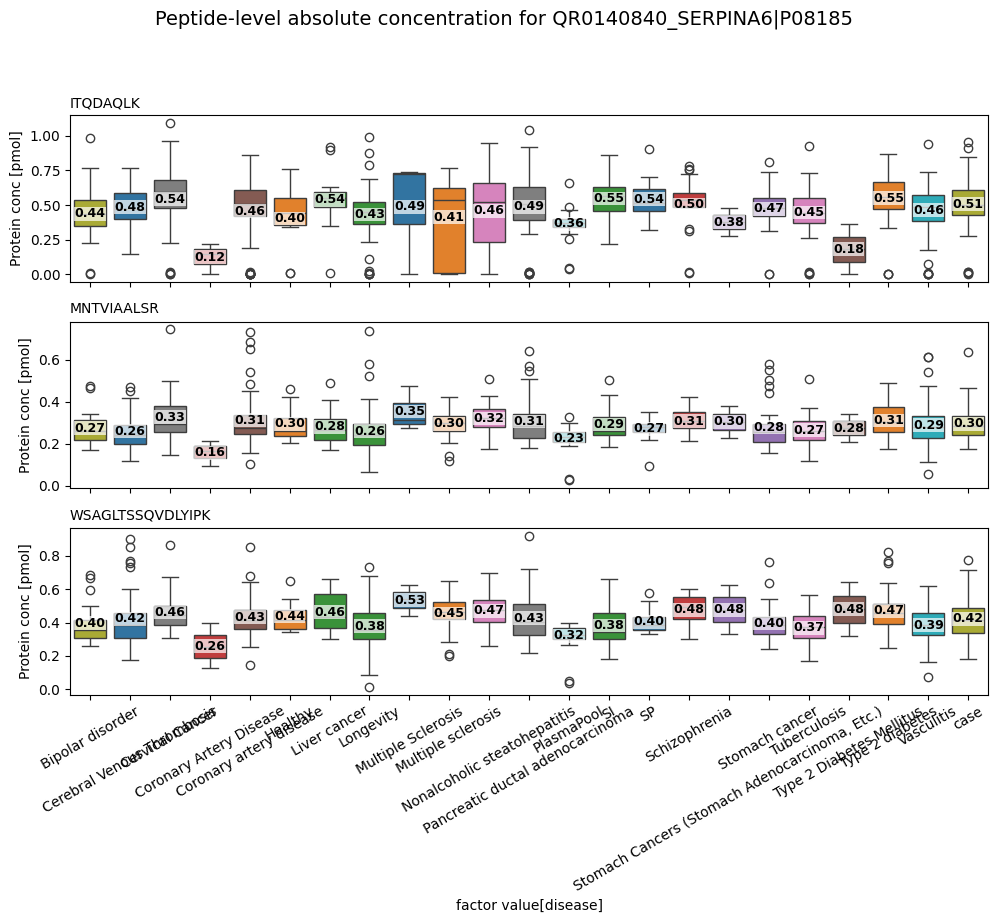

In [98]:
plot_peptide_concentration_by_group(
    abs_df,
    sdrf_data_file,
    group_col="factor value[disease]",
    protein_name="QR0140840_SERPINA6|P08185",  # from abs_df.reset_index()['Protein Name'].unique()
)


In [ ]:
plot_all_peptide_concentration_by_group(
    abs_df,
    sdrf_data_file,
    group_col="factor value[disease]",
    pdf_path="peptide_concentration_by_group.pdf",
)


In [ ]:
# duplicate removed — use cell 53
